# Thyroid/Diabetes Classification Pipeline

In [5]:
%pip install matplotlib pandas scikit-learn ucimlrepo seaborn numpy

Note: you may need to restart the kernel to use updated packages.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, roc_curve, auc


## Dataset
### Name: Diabetes 130-US hospitals for years 1999-2008
### Source: UCI ML Repository

### ID: 168

In [ ]:
from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=296)
print("Loaded Diabetes 130-US Hospitals for Years 1999-2008")
print(ds.metadata)

Loaded Diabetes 130-US Hospitals for Years 1999-2008
{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail 

c:\Users\haniu\anaconda3\Lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


## Preprocessing and train/test split (80-20)

In [8]:

X = ds.data.features
y = ds.data.targets

# find missing values
missing_cols = X.columns[X.isnull().any()].tolist()
print("Columns with missing values:", missing_cols)

# If there are missing values, we can fill them with median
X_clean = X.fillna(X.median(numeric_only=True))

# Remove non-numeric columns for simplicity
X_clean = X_clean.select_dtypes(include=[np.number])

# Convert target to binary: readmitted within 30 days vs not
y_binary = (y['readmitted'] == '<30').astype(int)

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_binary, test_size=0.2, stratify=y_binary, random_state=42)

Columns with missing values: ['race', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult']


## Model pipeline: MLP CLassifier

In [9]:
mlp_pipe = Pipeline([
	("scaler", StandardScaler()),
	("mlp", MLPClassifier( max_iter=1000, random_state=42))
])

## Model pipeline: SVM

In [10]:
svm_pipe = Pipeline([
	("scaler", StandardScaler()),
	("svm", SVC(kernel="rbf", probability=True, random_state=42))
])

## Cross-validated predictions on training set and final test evaluation

### Cross validation method: K-fold

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(pipe, X_tr, y_tr, X_te, y_te, cv):
	# cross-validated predictions on training set
	y_pred_cv = cross_val_predict(pipe, X_tr, y_tr, cv=cv, method="predict")
	p, r, f1, _ = precision_recall_fscore_support(y_tr, y_pred_cv, average="binary")
	acc_cv = accuracy_score(y_tr, y_pred_cv)

	# fit on full train and evaluate on test
	pipe.fit(X_tr, y_tr)
	y_pred_test = pipe.predict(X_te)
	p_t, r_t, f1_t, _ = precision_recall_fscore_support(y_te, y_pred_test, average="binary")
	acc_t = accuracy_score(y_te, y_pred_test)

	return {
		"cv": {"precision": p, "recall": r, "f1": f1, "accuracy": acc_cv},
		"test": {"precision": p_t, "recall": r_t, "f1": f1_t, "accuracy": acc_t},
		"model": pipe,
		"y_pred_test": y_pred_test,
	}

## Model Evaluation

In [ ]:
results_mlp = evaluate_model(mlp_pipe, X_train, y_train, X_test, y_test, cv)
results_svm = evaluate_model(svm_pipe, X_train, y_train, X_test, y_test, cv)

## Results

In [ ]:
def print_results(name, res):
	print(f"--- {name} ---")
	print("Cross-val (train) metrics:")
	for k, v in res["cv"].items():
		print(f"  {k}: {v:.4f}")
	print("Test metrics:")
	for k, v in res["test"].items():
		print(f"  {k}: {v:.4f}")


print_results("MLPClassifier", results_mlp)
print_results("SVM", results_svm)

--- MLPClassifier ---
Cross-val (train) metrics:
  precision: 0.7264
  recall: 0.6937
  f1: 0.7097
  accuracy: 0.7397
Test metrics:
  precision: 0.7500
  recall: 0.9643
  f1: 0.8438
  accuracy: 0.8361
--- SVM ---
Cross-val (train) metrics:
  precision: 0.8400
  recall: 0.7568
  f1: 0.7962
  accuracy: 0.8223
Test metrics:
  precision: 0.8065
  recall: 0.8929
  f1: 0.8475
  accuracy: 0.8525


## Visual Comparison

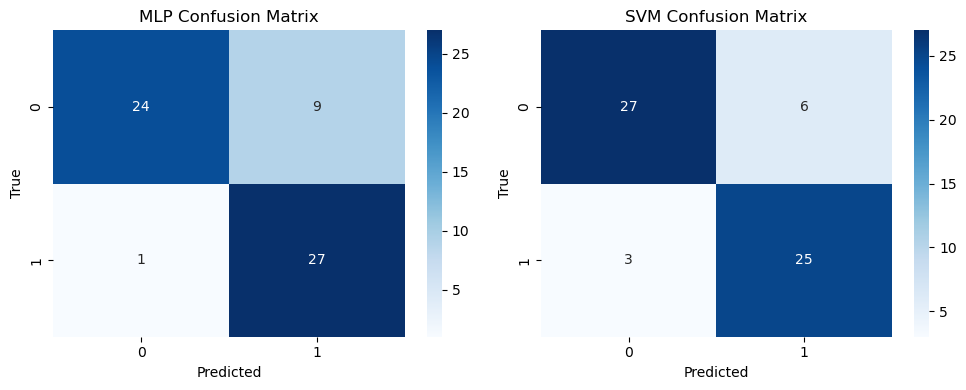

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, res) in zip(axes, [("MLP", results_mlp), ("SVM", results_svm)]):
	cm = confusion_matrix(y_test, res["y_pred_test"])
	sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues")
	ax.set_title(f"{name} Confusion Matrix")
	ax.set_xlabel("Predicted")
	ax.set_ylabel("True")
plt.tight_layout()
plt.show()

## Confusion matrices for both models

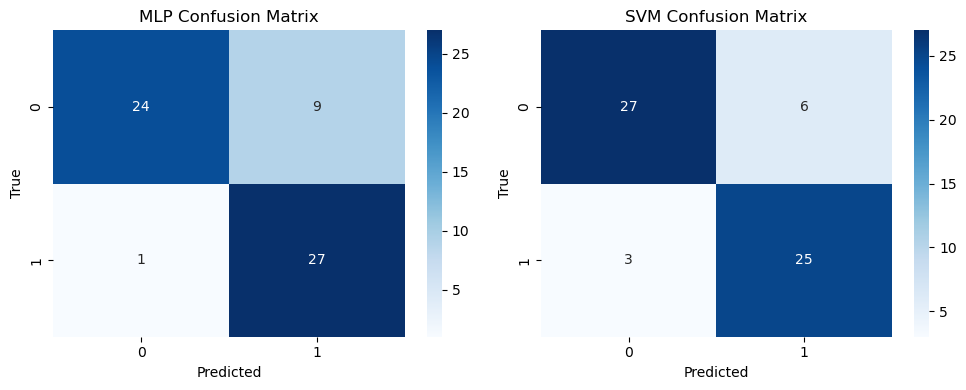

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, res) in zip(axes, [("MLP", results_mlp), ("SVM", results_svm)]):
	cm = confusion_matrix(y_test, res["y_pred_test"])
	sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues")
	ax.set_title(f"{name} Confusion Matrix")
	ax.set_xlabel("Predicted")
	ax.set_ylabel("True")
plt.tight_layout()
plt.show()

## ROC curves (AUC) for models

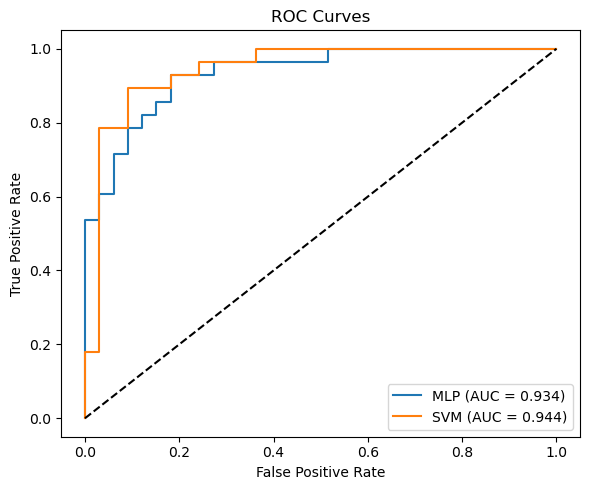

In [ ]:
plt.figure(figsize=(6, 5))
for name, pipe in [("MLP", results_mlp["model"]), ("SVM", results_svm["model"])]:
	if hasattr(pipe.named_steps[list(pipe.named_steps.keys())[-1]], "predict_proba"):
		y_score = pipe.predict_proba(X_test)[:, 1]
	else:
		y_score = pipe.decision_function(X_test)
	fpr, tpr, _ = roc_curve(y_test, y_score)
	roc_auc = auc(fpr, tpr)
	plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

## PCA experiments
##  2-component visualization and PCA->95% variance comparison

In [ ]:
for n_comp in (2,):
	pca_pipe = Pipeline([
		("scaler", StandardScaler()),
		("pca", PCA(n_components=n_comp)),
	])
	X_train_p = pca_pipe.fit_transform(X_train)
	X_test_p = pca_pipe.transform(X_test)

	mlp_p = MLPClassifier(max_iter=1000, random_state=42)
	svm_p = SVC(kernel="rbf", probability=True, random_state=42)

	mlp_p.fit(X_train_p, y_train)
	svm_p.fit(X_train_p, y_train)

	y_mlp_p = mlp_p.predict(X_test_p)
	y_svm_p = svm_p.predict(X_test_p)

	print(f"PCA {n_comp} comps - MLP test accuracy: {accuracy_score(y_test, y_mlp_p):.4f}")
	print(f"PCA {n_comp} comps - SVM test accuracy: {accuracy_score(y_test, y_svm_p):.4f}")


PCA 2 comps - MLP test accuracy: 0.8689
PCA 2 comps - SVM test accuracy: 0.8197


## PCA explained-variance experiment (retain 95% variance)

In [ ]:
pca95 = Pipeline([
	("scaler", StandardScaler()),
	("pca", PCA(n_components=0.95)),
])
X_train_95 = pca95.fit_transform(X_train)
X_test_95 = pca95.transform(X_test)

print(f"Components to explain 95% variance: {X_train_95.shape[1]}")

mlp_95 = MLPClassifier( max_iter=1000, random_state=42)
svm_95 = SVC(kernel="rbf", probability=True, random_state=42)

mlp_95.fit(X_train_95, y_train)
svm_95.fit(X_train_95, y_train)

print(f"MLP on PCA95 acc: {accuracy_score(y_test, mlp_95.predict(X_test_95)):.4f}")
print(f"SVM on PCA95 acc: {accuracy_score(y_test, svm_95.predict(X_test_95)):.4f}")

Components to explain 95% variance: 12
MLP on PCA95 acc: 0.8197
SVM on PCA95 acc: 0.8689
